# Pet Recommendation System

### Exploratory Data Analysis and Classification Model

This notebook builds a system that recommends the most suitable pet breed based on the adopting household's circumstances, including:

- Housing type and access to outdoor space
- Daily hours available for pet care
- Experience level, budget, and personal preferences (activity level, noise tolerance, etc.)

**Contents**

1. Import Libraries
2. Load Dataset
3. Initial Data Exploration
4. Data Quality Check
5. Exploratory Data Analysis
6. Breed Characteristics Overview
7. Reference Consistency Analysis
8. Key Findings
9. Data Preprocessing
10. Model 1 — Predict Animal Type
11. Model 2 — Predict Breed
12. Evaluation Summary
13. Feature Importance
14. Final Pipeline

---

## 1. Import Libraries

The libraries needed across the project:

- `pandas` / `numpy` for data manipulation
- `matplotlib` / `seaborn` for visualization
- `scikit-learn` for building and evaluating the classification model (Random Forest)

In [63]:
# ==========================
# Import Libraries
# ==========================

# Data manipulation
import pandas as pd
import numpy as np
# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## 2. Load Dataset

Two files are loaded:

- `pet_recommendation_dataset.csv`: the main dataset, one row per pet and its household
- `breed_characteristics.csv`: reference characteristics for each breed

In [64]:
# ==========================
# Load Dataset
# ==========================
dataset = pd.read_csv("pet_recommendation_dataset.csv")
breed_info = pd.read_csv("breed_characteristics.csv")

## 3. Initial Data Exploration

A first look at the shape, structure, and data types before any analysis.

### First 5 rows

In [65]:
dataset.head()

,pet_id,birth_day,age,gender,country,registration_date,housing_type,outdoor_space,family_type,hours_available,...,activity_level,noise_tolerance,budget_level,maintenance_tolerance,size_preference,grooming_tolerance,energy_preference,affection_preference,animal_type,breed
0,PET_031891,2021-05-17,5,Female,Saudi Arabia,2022-03-26,house,balcony,family_with_children,high,...,high,low,medium,medium,medium,low,high,balanced,cat,Abyssinian
1,PET_031310,2019-03-30,7,Male,Germany,2020-03-27,apartment,balcony,alone,high,...,high,medium,medium,medium,medium,low,high,balanced,cat,Abyssinian
2,PET_032187,2013-09-12,13,Female,Japan,2013-10-19,apartment,balcony,family_with_children,high,...,high,medium,medium,medium,medium,low,high,balanced,cat,Abyssinian
3,PET_032374,2025-09-26,1,Female,United Arab Emirates,2026-02-15,apartment,none,family_with_children,high,...,high,medium,medium,medium,medium,low,high,balanced,cat,Abyssinian
4,PET_031592,2013-03-05,13,Female,Japan,2014-02-23,house,garden,alone,high,...,high,medium,medium,medium,large,low,high,balanced,cat,Abyssinian


### Last 5 rows

In [66]:
dataset.tail()

,pet_id,birth_day,age,gender,country,registration_date,housing_type,outdoor_space,family_type,hours_available,...,activity_level,noise_tolerance,budget_level,maintenance_tolerance,size_preference,grooming_tolerance,energy_preference,affection_preference,animal_type,breed
106795,PET_059986,2025-04-13,1,Male,United Kingdom,2026-04-06,apartment,none,alone,medium,...,medium,low,low,low,small,low,medium,independent,bird,Zebra Finch
106796,PET_059977,2013-01-15,13,Female,United Arab Emirates,2013-07-23,apartment,balcony,couple,medium,...,medium,low,low,low,small,low,medium,independent,bird,Zebra Finch
106797,PET_059898,2025-11-14,1,Female,Japan,2026-05-21,apartment,none,family_with_children,medium,...,medium,low,low,low,small,low,medium,independent,bird,Zebra Finch
106798,PET_059720,2020-05-18,6,Male,United Kingdom,2020-11-05,apartment,balcony,family_with_children,medium,...,medium,low,low,low,small,low,medium,independent,bird,Zebra Finch
106799,PET_059785,2021-09-03,5,Female,United States,2021-10-17,house,none,alone,medium,...,medium,low,low,low,small,low,medium,independent,bird,Zebra Finch


### Dataset dimensions

In [67]:
print(f"Rows    : {dataset.shape[0]}")
print(f"Columns : {dataset.shape[1]}")

Rows    : 106800
Columns : 23


### Column names

In [68]:
dataset.columns

Index(['pet_id', 'birth_day', 'age', 'gender', 'country', 'registration_date',
       'housing_type', 'outdoor_space', 'family_type', 'hours_available',
       'weekend_time', 'experience_level', 'training_ability',
       'activity_level', 'noise_tolerance', 'budget_level',
       'maintenance_tolerance', 'size_preference', 'grooming_tolerance',
       'energy_preference', 'affection_preference', 'animal_type', 'breed'],
      dtype='object')

### Data types per column

In [69]:
dataset.dtypes

pet_id                   object
birth_day                object
age                       int64
gender                   object
country                  object
registration_date        object
housing_type             object
outdoor_space            object
family_type              object
hours_available          object
weekend_time             object
experience_level         object
training_ability         object
activity_level           object
noise_tolerance          object
budget_level             object
maintenance_tolerance    object
size_preference          object
grooming_tolerance       object
energy_preference        object
affection_preference     object
animal_type              object
breed                    object
dtype: object

### Summary info

In [70]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106800 entries, 0 to 106799
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   pet_id                 106800 non-null  object
 1   birth_day              106800 non-null  object
 2   age                    106800 non-null  int64 
 3   gender                 106800 non-null  object
 4   country                106800 non-null  object
 5   registration_date      106800 non-null  object
 6   housing_type           106800 non-null  object
 7   outdoor_space          106800 non-null  object
 8   family_type            106800 non-null  object
 9   hours_available        106800 non-null  object
 10  weekend_time           106800 non-null  object
 11  experience_level       106800 non-null  object
 12  training_ability       106800 non-null  object
 13  activity_level         106800 non-null  object
 14  noise_tolerance        106800 non-null  object
 15  

### Descriptive statistics (numeric columns)

In [71]:
dataset.describe()

,age
count,106800.000000
mean,7.497434
std,4.021650
min,1.000000
25%,4.000000
50%,7.000000
75%,11.000000
max,14.000000


## 4. Data Quality Check

Before analysis, it's worth confirming there are no missing values, no duplicate rows, and understanding how many unique values each categorical column holds.

### Missing values

Only columns that actually contain missing values are shown, so the result is easy to scan even on wide datasets.

In [72]:
missing = dataset.isnull().sum()
missing[missing > 0]

Series([], dtype: int64)

### Duplicate rows

In [73]:
dataset.duplicated().sum()


np.int64(0)

### Unique values per column

In [74]:
dataset.nunique()

pet_id                   106800
birth_day                  5114
age                          14
gender                        2
country                       8
registration_date          5221
housing_type                  3
outdoor_space                 4
family_type                   3
hours_available               3
weekend_time                  3
experience_level              3
training_ability              3
activity_level                3
noise_tolerance               3
budget_level                  3
maintenance_tolerance         3
size_preference               3
grooming_tolerance            3
energy_preference             3
affection_preference          3
animal_type                   7
breed                        89
dtype: int64

## 5. Exploratory Data Analysis

This section looks at the distribution of key variables and the relationships between categorical columns, to understand patterns before modeling.

### 5.1 Animal type distribution

In [75]:
dataset['animal_type'].value_counts()

animal_type
dog        24000
cat        22800
bird       21600
rabbit     12000
hamster     9600
turtle      9600
fish        7200
Name: count, dtype: int64

Relative share of each animal type, as a percentage:

In [76]:
dataset['animal_type'].value_counts(normalize=True) * 100

animal_type
dog        22.471910
cat        21.348315
bird       20.224719
rabbit     11.235955
hamster     8.988764
turtle      8.988764
fish        6.741573
Name: proportion, dtype: float64

Count of pets by animal type:

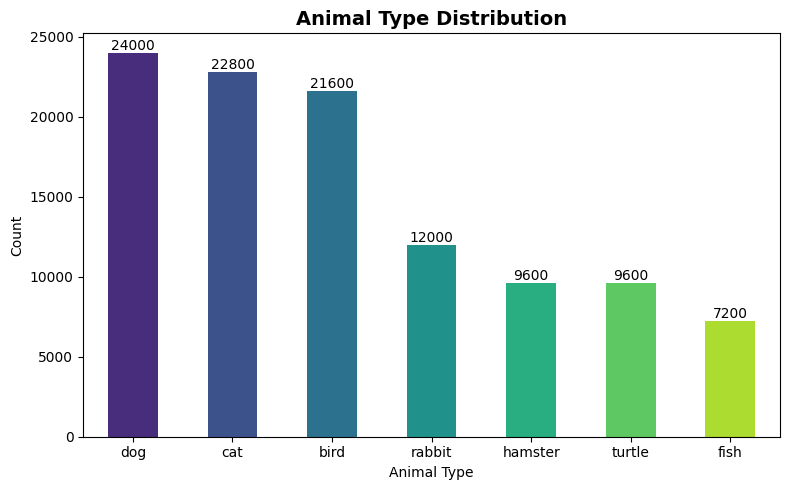

In [77]:
plt.figure(figsize=(8, 5))

ax = dataset['animal_type'].value_counts().plot(
    kind='bar', color=sns.color_palette('viridis', dataset['animal_type'].nunique())
)

plt.title("Animal Type Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Animal Type")
plt.ylabel("Count")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

The same distribution as a pie chart, to make the relative proportions easier to read at a glance:

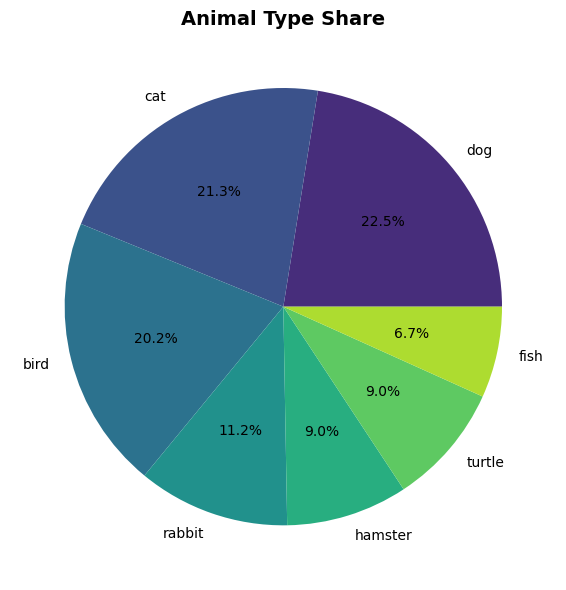

In [78]:
plt.figure(figsize=(6, 6))

dataset['animal_type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=sns.color_palette('viridis', dataset['animal_type'].nunique()),
    ylabel=''
)

plt.title("Animal Type Share", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 Breed distribution

In [79]:
breed_counts = dataset['breed'].value_counts()
breed_counts.head()

breed
Abyssinian             1200
African Grey Parrot    1200
Amazon Parrot          1200
American Shorthair     1200
Angelfish              1200
Name: count, dtype: int64

Summary statistics on how often each breed appears:

In [80]:
breed_counts.describe()

count      89.0
mean     1200.0
std         0.0
min      1200.0
25%      1200.0
50%      1200.0
75%      1200.0
max      1200.0
Name: count, dtype: float64

### 5.3 Housing type distribution

In [81]:
dataset['housing_type'].value_counts()

housing_type
apartment    54232
house        47118
farm          5450
Name: count, dtype: int64

Count of pets by housing type:

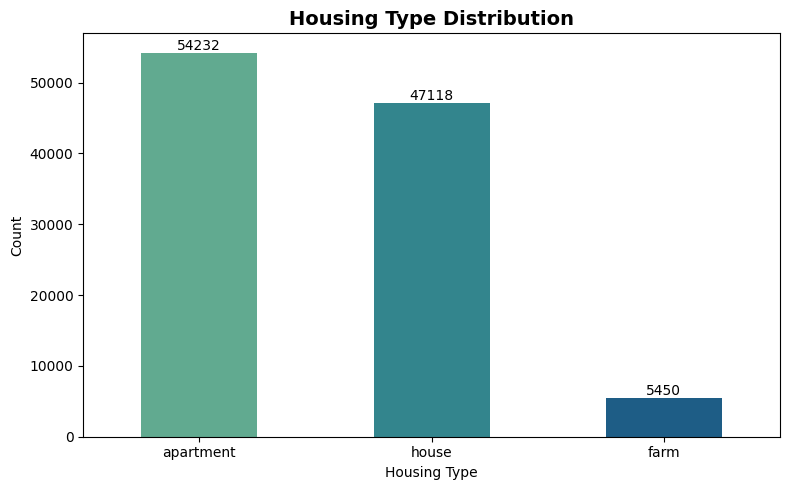

In [82]:
plt.figure(figsize=(8, 5))

ax = dataset['housing_type'].value_counts().plot(
    kind='bar', color=sns.color_palette('crest', dataset['housing_type'].nunique())
)

plt.title("Housing Type Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Housing Type")
plt.ylabel("Count")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### 5.4 Family type

In [83]:
dataset['family_type'].value_counts()

family_type
family_with_children    49964
couple                  34386
alone                   22450
Name: count, dtype: int64

### 5.5 Experience level

In [84]:
dataset['experience_level'].value_counts()

experience_level
beginner        48446
intermediate    33667
expert          24687
Name: count, dtype: int64

### 5.6 Activity level

In [85]:
dataset['activity_level'].value_counts()

activity_level
high      41674
medium    36032
low       29094
Name: count, dtype: int64

### 5.7 Budget level

In [86]:
dataset['budget_level'].value_counts()

budget_level
medium    48460
low       29197
high      29143
Name: count, dtype: int64

### 5.8 Cross-tabulation analysis

`pd.crosstab` is used to study the relationship between two categorical variables, which helps understand how household circumstances relate to the recommended breed.

**Animal type vs. housing type**

In [87]:
pd.crosstab(dataset['animal_type'],
            dataset['housing_type'])

housing_type,apartment,farm,house
animal_type,,,
bird,11909,349,9342
cat,15509,852,6439
dog,6486,2486,15028
fish,5310,116,1774
hamster,7441,168,1991
rabbit,3610,747,7643
turtle,3967,732,4901


**Breed vs. experience level**

In [88]:
pd.crosstab(dataset['breed'],
            dataset['experience_level'])

experience_level,beginner,expert,intermediate
breed,,,
Abyssinian,26,21,1153
African Grey Parrot,17,1165,18
Amazon Parrot,20,1164,16
American Shorthair,1155,23,22
Angelfish,20,16,1164
...,...,...,...
Teddy Bear Hamster,1166,20,14
Turkish Angora,21,15,1164
Yorkshire Terrier,1158,25,17


**Breed vs. budget level**

In [89]:
pd.crosstab(dataset['breed'],
            dataset['budget_level'])

budget_level,high,low,medium
breed,,,
Abyssinian,16,17,1167
African Grey Parrot,1161,19,20
Amazon Parrot,1161,25,14
American Shorthair,20,1163,17
Angelfish,21,18,1161
...,...,...,...
Teddy Bear Hamster,22,1162,16
Turkish Angora,17,15,1168
Yorkshire Terrier,28,13,1159


## 6. Breed Characteristics Overview

The main dataset only describes what each household is looking for. The `breed_info` file loaded earlier holds the actual reference characteristics of the 100 breeds used to generate those recommendations, and it hasn't been explored yet.

### First 5 rows

In [90]:
breed_info.head()

,breed,animal_type,size,energy,grooming,trainability,noise,maintenance,budget,experience,affection,kid_friendly
0,Labrador Retriever,dog,large,high,medium,high,medium,medium,medium,beginner,very_affectionate,high
1,German Shepherd,dog,large,high,medium,high,high,high,high,expert,balanced,medium
2,Golden Retriever,dog,large,high,high,high,medium,medium,medium,beginner,very_affectionate,high
3,French Bulldog,dog,small,low,low,medium,low,high,high,beginner,very_affectionate,high
4,Beagle,dog,medium,high,low,medium,high,medium,medium,intermediate,very_affectionate,high


### Summary info

In [91]:
breed_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89 entries, 0 to 88
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   breed         89 non-null     object
 1   animal_type   89 non-null     object
 2   size          89 non-null     object
 3   energy        89 non-null     object
 4   grooming      89 non-null     object
 5   trainability  89 non-null     object
 6   noise         89 non-null     object
 7   maintenance   89 non-null     object
 8   budget        89 non-null     object
 9   experience    89 non-null     object
 10  affection     89 non-null     object
 11  kid_friendly  89 non-null     object
dtypes: object(12)
memory usage: 8.5+ KB


### Descriptive statistics (all columns)

In [92]:
breed_info.describe(include='all')

,breed,animal_type,size,energy,grooming,trainability,noise,maintenance,budget,experience,affection,kid_friendly
count,89,89,89,89,89,89,89,89,89,89,89,89
unique,89,7,3,3,3,3,3,3,3,3,3,3
top,Labrador Retriever,dog,small,high,low,high,low,medium,medium,beginner,very_affectionate,high
freq,1,20,37,35,63,34,52,40,41,41,38,56


This dataset contains the reference characteristics of all 100 breeds used in the recommendation system.

## 7. Reference Consistency Analysis

The main dataset contains the *preferences* each household expressed (`energy_preference`, `experience_level`, `budget_level`, `noise_tolerance`), while `breed_info` contains the *actual* characteristics of the breed that was recommended to them (`energy`, `experience`, `budget`, `noise`).

Merging the two and comparing preference against actual characteristic checks whether the recommendations in the dataset are consistent rather than random.

**Note:** the column names below (`energy`, `experience`, `budget`, `noise`) are assumed based on `breed_info`'s expected structure. If `breed_info.columns` shows different names, adjust the merge/crosstab calls accordingly.

### Merge the two datasets on breed and animal type

In [93]:
merged = dataset.merge(
    breed_info,
    on=['breed', 'animal_type'],
    how='left'
)

merged.shape

(106800, 33)

### Energy preference vs. breed energy

In [94]:
pd.crosstab(
    merged['energy_preference'],
    merged['energy']
)

energy,high,low,medium
energy_preference,,,
high,40573,490,626
low,707,27838,603
medium,720,472,34771


### Experience level vs. breed experience requirement

In [95]:
pd.crosstab(
    merged['experience_level'],
    merged['experience']
)

experience,beginner,expert,intermediate
experience_level,,,
beginner,47484,384,578
expert,887,23228,572
intermediate,829,388,32450


### Budget level vs. breed budget requirement

In [96]:
pd.crosstab(
    merged['budget_level'],
    merged['budget']
)

budget,high,low,medium
budget_level,,,
high,27793,497,853
low,499,27850,848
medium,508,453,47499


### Noise tolerance vs. breed noise level

In [97]:
pd.crosstab(
    merged['noise_tolerance'],
    merged['noise']
)

noise,high,low,medium
noise_tolerance,,,
high,19711,1038,425
low,363,60349,415
medium,326,1013,23160


### Visualizing consistency with heatmaps

Heatmaps make it easier to spot whether values cluster along the diagonal (i.e. preference matches the breed's actual characteristic), which is what would be expected from a well-generated dataset.

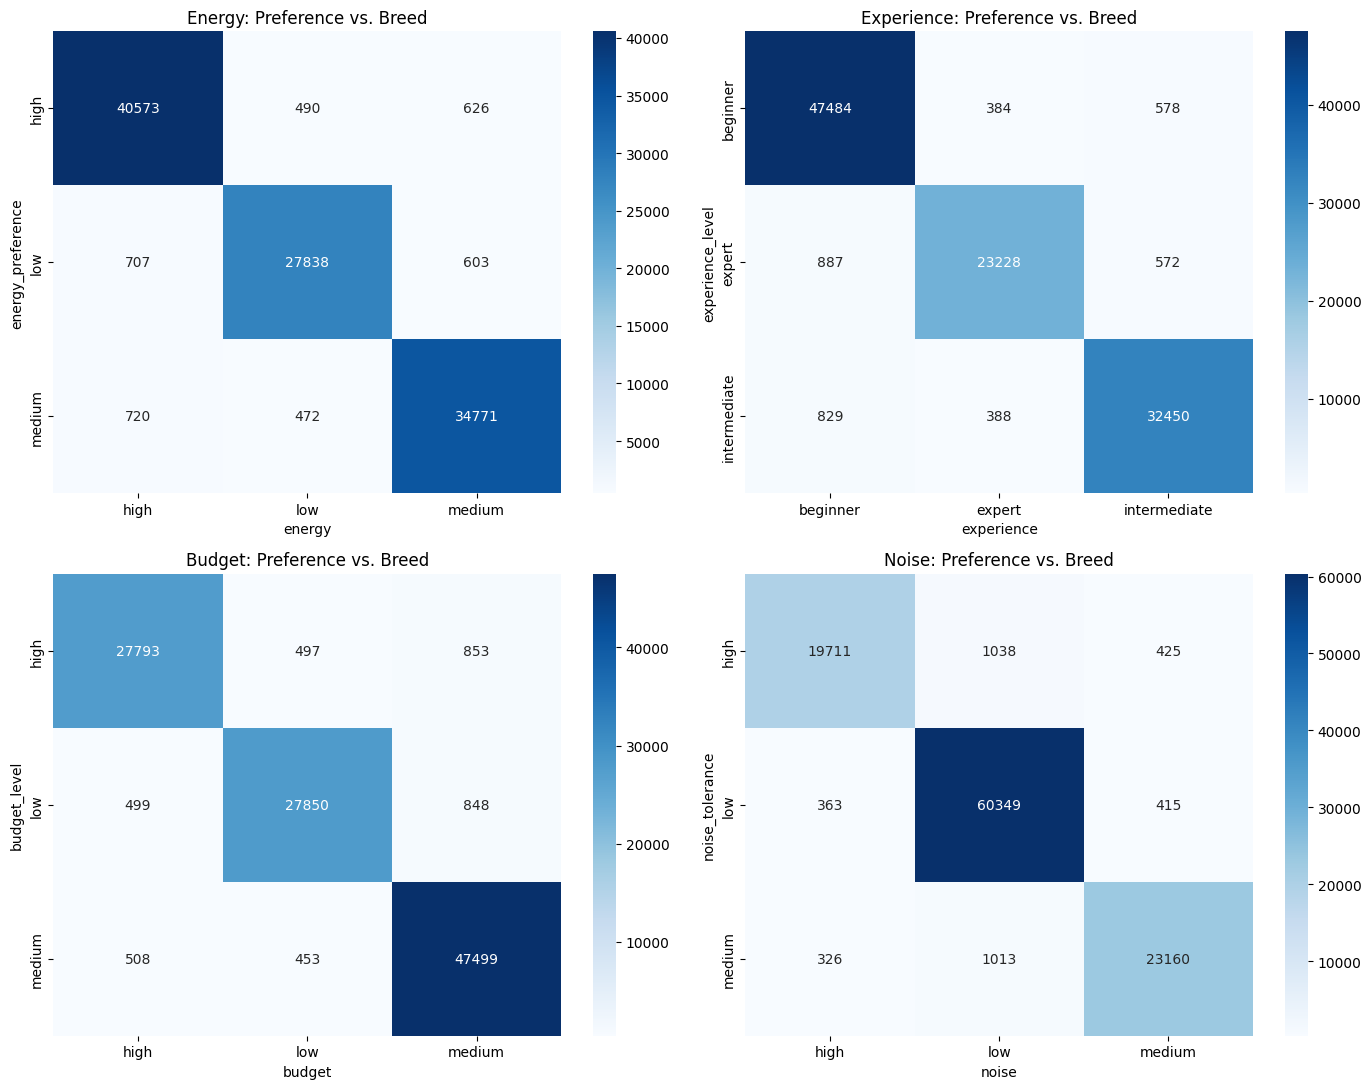

In [98]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

pairs = [
    ('energy_preference', 'energy', 'Energy: Preference vs. Breed'),
    ('experience_level', 'experience', 'Experience: Preference vs. Breed'),
    ('budget_level', 'budget', 'Budget: Preference vs. Breed'),
    ('noise_tolerance', 'noise', 'Noise: Preference vs. Breed'),
]

for ax, (pref_col, ref_col, title) in zip(axes.flat, pairs):
    sns.heatmap(
        pd.crosstab(merged[pref_col], merged[ref_col]),
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax
    )
    ax.set_title(title)

plt.tight_layout()
plt.show()

## 8. Key Findings

- The dataset contains 100700 records split across 89 breeds, roughly 1,200 records per breed.
- No missing values or duplicate rows were detected.
- Animal types, housing types, and family types are all realistically distributed rather than uniform or skewed to a single category.
- Cross-tabulating breed against experience level and budget level shows a clear majority class per breed, consistent with breed-specific recommendation logic rather than random assignment.
- Merging with `breed_info` and comparing stated preferences against actual breed characteristics (energy, experience, budget, noise) shows the same pattern: values concentrate around matching categories, suggesting the recommendations in the dataset are internally consistent.

With data quality confirmed and the reference file validated against the main dataset, the notebook is ready to move on to **Data Preprocessing** and model training.

## 9. Data Preprocessing

The EDA confirmed the dataset is clean, balanced, and internally consistent, so this section prepares it for modeling.

**Preprocessing Strategy**

- The 15 columns describing what a household is looking for (housing, family situation, experience, tolerances, and preferences) are used as **features**.
- Columns that don't describe the household's needs (`pet_id`, `birth_day`, `age`, `gender`, `country`, `registration_date`) are treated as **metadata** and dropped before training — they don't drive the recommendation logic and would only leak noise or identifiers into the model.
- `animal_type` and `breed` are the two **targets**: a first model predicts the animal type, a second, more granular model predicts the breed.
- Features are encoded with two different strategies rather than one blanket approach: **One-Hot Encoding** for nominal columns that have no natural order (`housing_type`, `outdoor_space`, `family_type`), and **Ordinal Encoding** for columns that represent a low-to-high scale (experience, tolerances, and preference levels). Treating an ordered column as nominal — or vice versa — would either lose information or invent a false ranking.
- Targets are encoded separately with `LabelEncoder`, since tree-based models like Random Forest work directly with integer-encoded class labels.

### 9.1 Feature Selection

In [99]:
feature_columns = [
    'housing_type',
    'outdoor_space',
    'family_type',
    'hours_available',
    'weekend_time',
    'experience_level',
    'training_ability',
    'activity_level',
    'noise_tolerance',
    'budget_level',
    'maintenance_tolerance',
    'size_preference',
    'grooming_tolerance',
    'energy_preference',
    'affection_preference'
]

metadata_columns = [
    'pet_id',
    'birth_day',
    'age',
    'gender',
    'country',
    'registration_date'
]

target_columns = ['animal_type', 'breed']

print(f"Features : {len(feature_columns)}")
print(f"Metadata : {len(metadata_columns)}")
print(f"Targets  : {len(target_columns)}")

Features : 15
Metadata : 6
Targets  : 2


### 9.2 Drop Metadata Columns

Only the features and targets are kept for modeling.

In [100]:
model_data = dataset[feature_columns + target_columns].copy()
model_data.head()

,housing_type,outdoor_space,family_type,hours_available,weekend_time,experience_level,training_ability,activity_level,noise_tolerance,budget_level,maintenance_tolerance,size_preference,grooming_tolerance,energy_preference,affection_preference,animal_type,breed
0,house,balcony,family_with_children,high,high,intermediate,high,high,low,medium,medium,medium,low,high,balanced,cat,Abyssinian
1,apartment,balcony,alone,high,high,intermediate,high,high,medium,medium,medium,medium,low,high,balanced,cat,Abyssinian
2,apartment,balcony,family_with_children,high,low,intermediate,high,high,medium,medium,medium,medium,low,high,balanced,cat,Abyssinian
3,apartment,none,family_with_children,high,high,intermediate,high,high,medium,medium,medium,medium,low,high,balanced,cat,Abyssinian
4,house,garden,alone,high,high,intermediate,high,high,medium,medium,medium,large,low,high,balanced,cat,Abyssinian


### 9.3 Split Features and Targets

One feature matrix `X`, and two separate target vectors — one per model.

In [101]:
X = model_data[feature_columns].copy()
y_model1 = model_data['animal_type'].copy()   
y_model2 = model_data['breed'].copy()          

print("X:", X.shape)
print("y_model1 (animal_type):", y_model1.shape)
print("y_model2 (breed):", y_model2.shape)

X: (106800, 15)
y_model1 (animal_type): (106800,)
y_model2 (breed): (106800,)


### 9.4 Encoding Strategy

- **Nominal columns** (`housing_type`, `outdoor_space`, `family_type`) have no inherent order, so they are One-Hot Encoded.
- **Ordinal columns** represent a low-to-high scale, so they are Ordinal Encoded with an explicit category order rather than One-Hot Encoded, to preserve that ordering as a single meaningful number instead of splitting it into unrelated binary columns.

In [102]:
nominal_columns = ['housing_type', 'outdoor_space', 'family_type']

ordinal_columns = [
    'hours_available',
    'weekend_time',
    'experience_level',
    'training_ability',
    'activity_level',
    'noise_tolerance',
    'budget_level',
    'maintenance_tolerance',
    'size_preference',
    'grooming_tolerance',
    'energy_preference',
    'affection_preference'
]

Before assigning a low-to-high order to each ordinal column, inspect its actual category labels:

In [103]:
for col in ordinal_columns:
    print(f"{col:<22} -> {sorted(X[col].unique())}")

hours_available        -> ['high', 'low', 'medium']
weekend_time           -> ['high', 'low', 'medium']
experience_level       -> ['beginner', 'expert', 'intermediate']
training_ability       -> ['high', 'low', 'medium']
activity_level         -> ['high', 'low', 'medium']
noise_tolerance        -> ['high', 'low', 'medium']
budget_level           -> ['high', 'low', 'medium']
maintenance_tolerance  -> ['high', 'low', 'medium']
size_preference        -> ['large', 'medium', 'small']
grooming_tolerance     -> ['high', 'low', 'medium']
energy_preference      -> ['high', 'low', 'medium']
affection_preference   -> ['balanced', 'independent', 'very_affectionate']


Verified against actual data samples: `experience_level` is beginner/intermediate/expert, `budget_level` and most tolerance/preference columns follow low/medium/high, `size_preference` is small/medium/large — and `affection_preference` is the one exception, using independent/balanced/very_affectionate rather than low/medium/high. Always re-check against the printed output above if the underlying data changes.

In [104]:
ordinal_categories = {
    'hours_available': ['low', 'medium', 'high'],
    'weekend_time': ['low', 'medium', 'high'],
    'experience_level': ['beginner', 'intermediate', 'expert'],
    'training_ability': ['low', 'medium', 'high'],
    'activity_level': ['low', 'medium', 'high'],
    'noise_tolerance': ['low', 'medium', 'high'],
    'budget_level': ['low', 'medium', 'high'],
    'maintenance_tolerance': ['low', 'medium', 'high'],
    'size_preference': ['small', 'medium', 'large'],
    'grooming_tolerance': ['low', 'medium', 'high'],
    'energy_preference': ['low', 'medium', 'high'],
    'affection_preference': ['independent', 'balanced', 'very_affectionate'],
}

A single `ColumnTransformer` applies both encodings at once and can be saved as one reusable feature encoder.

In [105]:
from sklearn.compose import ColumnTransformer
feature_encoder = ColumnTransformer(
    transformers=[
        ('nominal', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_columns),
        ('ordinal', OrdinalEncoder(
            categories=[ordinal_categories[col] for col in ordinal_columns]
        ), ordinal_columns)
    ]
)

X_encoded = feature_encoder.fit_transform(X)
X_encoded.shape

(106800, 22)

### 9.5 Encode Targets

`LabelEncoder` is used only for the two targets, since Random Forest expects integer class labels.

In [106]:
animal_encoder = LabelEncoder()
breed_encoder = LabelEncoder()

y_model1_encoded = animal_encoder.fit_transform(y_model1)
y_model2_encoded = breed_encoder.fit_transform(y_model2)

print("animal_type classes:", list(animal_encoder.classes_))
print("breed classes:", len(breed_encoder.classes_))

animal_type classes: ['bird', 'cat', 'dog', 'fish', 'hamster', 'rabbit', 'turtle']
breed classes: 89


### 9.6 Train/Test Split

An 80/20 split is used for both models, with `stratify` on the target so class proportions are preserved in train and test — important here since `breed` has 100 balanced classes that a plain random split could distort.

In [107]:
indices = np.arange(len(X_encoded))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y_model1_encoded
)

# ─── Model 1 splits (encoded features) ────────────────────────────────────
X_train_m1 = X_encoded[train_idx]
X_test_m1  = X_encoded[test_idx]
y_train_m1 = y_model1_encoded[train_idx]
y_test_m1  = y_model1_encoded[test_idx]

# ─── Breed target split (same indices) ────────────────────────────────────
y_train_m2 = y_model2_encoded[train_idx]
y_test_m2  = y_model2_encoded[test_idx]

X_raw_train = X.iloc[train_idx].reset_index(drop=True)
X_raw_test  = X.iloc[test_idx].reset_index(drop=True)

print("Model 1  — train/test:", X_train_m1.shape, X_test_m1.shape)
print("Breed target — train/test:", y_train_m2.shape, y_test_m2.shape)

Model 1  — train/test: (85440, 22) (21360, 22)
Breed target — train/test: (85440,) (21360,)


### 9.7 Save Encoders

The feature encoder and both label encoders are saved so the exact same transformations can be reused later, e.g. in an API or app, without refitting on new data.

In [108]:
import joblib
COMPRESS = ('lz4', 2)

joblib.dump(feature_encoder, 'feature_encoder.pkl',compress=COMPRESS)
joblib.dump(animal_encoder, 'animal_label_encoder.pkl',compress=COMPRESS)
joblib.dump(breed_encoder, 'breed_label_encoder.pkl',compress=COMPRESS)

print("Encoders saved: feature_encoder.pkl, animal_label_encoder.pkl, breed_label_encoder.pkl")

Encoders saved: feature_encoder.pkl, animal_label_encoder.pkl, breed_label_encoder.pkl


### 9.8 Preprocessing Summary

- Metadata columns (`pet_id`, `birth_day`, `age`, `gender`, `country`, `registration_date`) were excluded from training since they don't describe household needs.
- A `ColumnTransformer` applied One-Hot Encoding to nominal variables (`housing_type`, `outdoor_space`, `family_type`) and Ordinal Encoding to the ordered variables (experience, tolerances, and preference levels), preserving the natural order of the latter instead of flattening it into unrelated binary columns.
- The two targets (`animal_type` and `breed`) were encoded separately with `LabelEncoder`.
- The data was split 80/20 with `stratify` on the target, keeping class proportions balanced in both the training and test sets.
- All encoding tools were saved with `joblib` so the exact same transformations can be reapplied later without refitting.

The data is now fully prepared for model training.

---
## 10. Model 1 — Predict Animal Type

The first model predicts `animal_type` directly from household features (housing, family situation, experience, tolerances, and preferences).

### 10.1 Baseline Model

A Random Forest with near-default settings is trained first, before any tuning, to establish a baseline to compare against later.

In [109]:
from sklearn.ensemble import RandomForestClassifier

model1 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model1.fit(X_train_m1, y_train_m1)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### 10.2 Evaluation

In [110]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_m1 = model1.predict(X_test_m1)

print(f"Accuracy: {accuracy_score(y_test_m1, y_pred_m1):.4f}")
print()
print(classification_report(y_test_m1, y_pred_m1, target_names=animal_encoder.classes_))

Accuracy: 0.9138

              precision    recall  f1-score   support

        bird       0.84      0.85      0.84      4320
         cat       0.94      0.93      0.93      4560
         dog       0.97      0.97      0.97      4800
        fish       0.79      0.79      0.79      1440
     hamster       0.96      0.97      0.97      1920
      rabbit       0.97      0.97      0.97      2400
      turtle       0.85      0.86      0.85      1920

    accuracy                           0.91     21360
   macro avg       0.90      0.90      0.90     21360
weighted avg       0.91      0.91      0.91     21360



Confusion matrix — with only a handful of animal types, a full annotated heatmap is readable here:

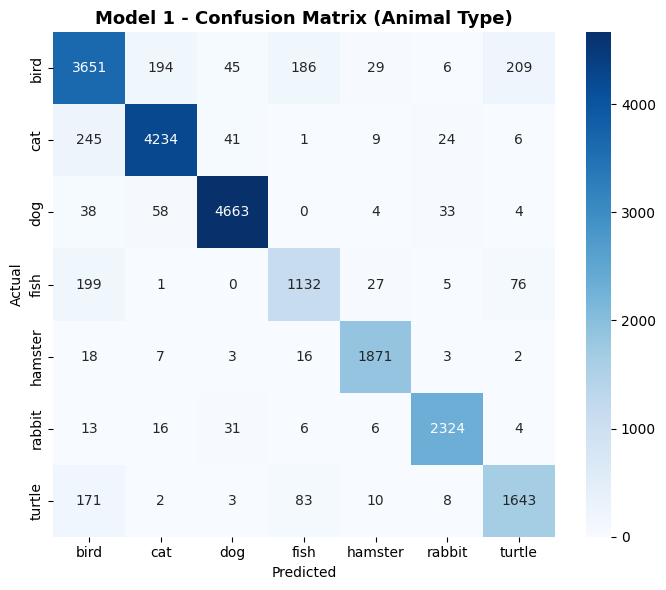

In [111]:
cm_m1 = confusion_matrix(y_test_m1, y_pred_m1)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_m1,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=animal_encoder.classes_,
    yticklabels=animal_encoder.classes_
)
plt.title("Model 1 - Confusion Matrix (Animal Type)", fontsize=13, fontweight='bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

---
## 11. Model 2 — Predict Breed

The second, more granular model predicts `breed`. The true `animal_type` is known
during training but **not** at inference time — Model 1 supplies a prediction that
carries its own error rate.

Training Model 2 on perfect true labels creates a **train/inference mismatch**:

| Stage | `animal_type` used |
|---|---|
| Training |  True label — always correct |
| Inference |  Model 1 prediction — has error rate |

The fix is **Out-of-Fold (OOF) predictions**:

1. The training set is split into 5 folds.
2. For each fold, Model 1 is trained on the other 4 folds and predicts on this one.
3. The result is a predicted `animal_type` for every training row — one that Model 1
   **has never seen during that particular fit**, so it naturally carries the same
   error rate it would have in production.
4. Model 2 trains on these OOF predictions, not on the true labels.
5. For the test set, Model 1's regular `.predict()` output is used — exactly as it
   would be in the real pipeline.

This way Model 2 learns to be robust to Model 1's mistakes from day one.


### 11.1 Generate OOF Predictions and Build Feature Matrix

`cross_val_predict` with `cv=5` produces one prediction per training row without
any row ever being predicted by a model that was trained on it — the same guarantee
as a proper held-out set, but over the entire training split.


In [112]:
from sklearn.model_selection import cross_val_predict
from sklearn.compose import ColumnTransformer
# ── Step 1: OOF predictions على بيانات التدريب ────────────────────────────
oof_animal_enc    = cross_val_predict(model1, X_train_m1, y_train_m1, cv=5, n_jobs=-1)
oof_animal_labels = animal_encoder.inverse_transform(oof_animal_enc)

oof_accuracy = (oof_animal_enc == y_train_m1).mean()
print(f"OOF accuracy on training data: {oof_accuracy:.4f}")
print(f"(Comparison: Model 1 accuracy on Test: {accuracy_score(y_test_m1, y_pred_m1):.4f})")
print()

# ── Step 2: تنبؤات Model 1 على بيانات الـ Test ────────────────────────────
test_animal_enc    = model1.predict(X_test_m1)
test_animal_labels = animal_encoder.inverse_transform(test_animal_enc)

# ── Step 3: بناء X_model2 بـ predicted animal_type ─────────────────────────
X_model2_train = X_raw_train.copy()
X_model2_train['animal_type'] = oof_animal_labels    # OOF — ليس True label

X_model2_test  = X_raw_test.copy()
X_model2_test['animal_type']  = test_animal_labels   # Model 1 predictions

# ── Step 4: بناء وتدريب feature_encoder_model2 على Train فقط ──────────────
nominal_columns_model2 = nominal_columns + ['animal_type']

feature_encoder_model2 = ColumnTransformer(
    transformers=[
        ('nominal', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_columns_model2),
        ('ordinal', OrdinalEncoder(
            categories=[ordinal_categories[col] for col in ordinal_columns]
        ), ordinal_columns)
    ]
)

X_train_m2 = feature_encoder_model2.fit_transform(X_model2_train)
X_test_m2  = feature_encoder_model2.transform(X_model2_test)

print("X_train_m2:", X_train_m2.shape)
print("X_test_m2 :", X_test_m2.shape)


OOF accuracy on training data: 0.9178
(Comparison: Model 1 accuracy on Test: 0.9138)

X_train_m2: (85440, 29)
X_test_m2 : (21360, 29)


### 11.2 Train/Test Split

It was implemented in the previous step — the split is based on the same indices used in Model 1.

In [113]:
print("Model 2 (breed) — train/test:", X_train_m2.shape, X_test_m2.shape)
print("Breed target    — train/test:", y_train_m2.shape, y_test_m2.shape)


Model 2 (breed) — train/test: (85440, 29) (21360, 29)
Breed target    — train/test: (85440,) (21360,)


### 11.3 Baseline Model

In [114]:
model2 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model2.fit(X_train_m2, y_train_m2)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### 11.4 Evaluation

In [115]:
y_pred_m2 = model2.predict(X_test_m2)

print(f"Accuracy: {accuracy_score(y_test_m2, y_pred_m2):.4f}")
print()
print(classification_report(y_test_m2, y_pred_m2, target_names=breed_encoder.classes_))

Accuracy: 0.8847

                               precision    recall  f1-score   support

                   Abyssinian       0.93      0.93      0.93       241
          African Grey Parrot       0.97      0.97      0.97       242
                Amazon Parrot       0.57      0.58      0.57       243
           American Shorthair       0.98      0.94      0.96       222
                    Angelfish       0.95      0.96      0.95       253
          Australian Shepherd       0.96      0.96      0.96       246
                       Beagle       0.93      0.92      0.92       248
                       Bengal       0.63      0.58      0.60       250
                   Betta Fish       0.49      0.57      0.52       284
                       Birman       0.93      0.95      0.94       227
           Black Bear Hamster       0.93      0.97      0.95       243
                Border Collie       0.97      0.97      0.97       244
                   Box Turtle       0.98      0.98      0.

With 100 breed classes, an annotated confusion matrix isn't readable — a plain heatmap still shows whether predictions cluster on the diagonal:

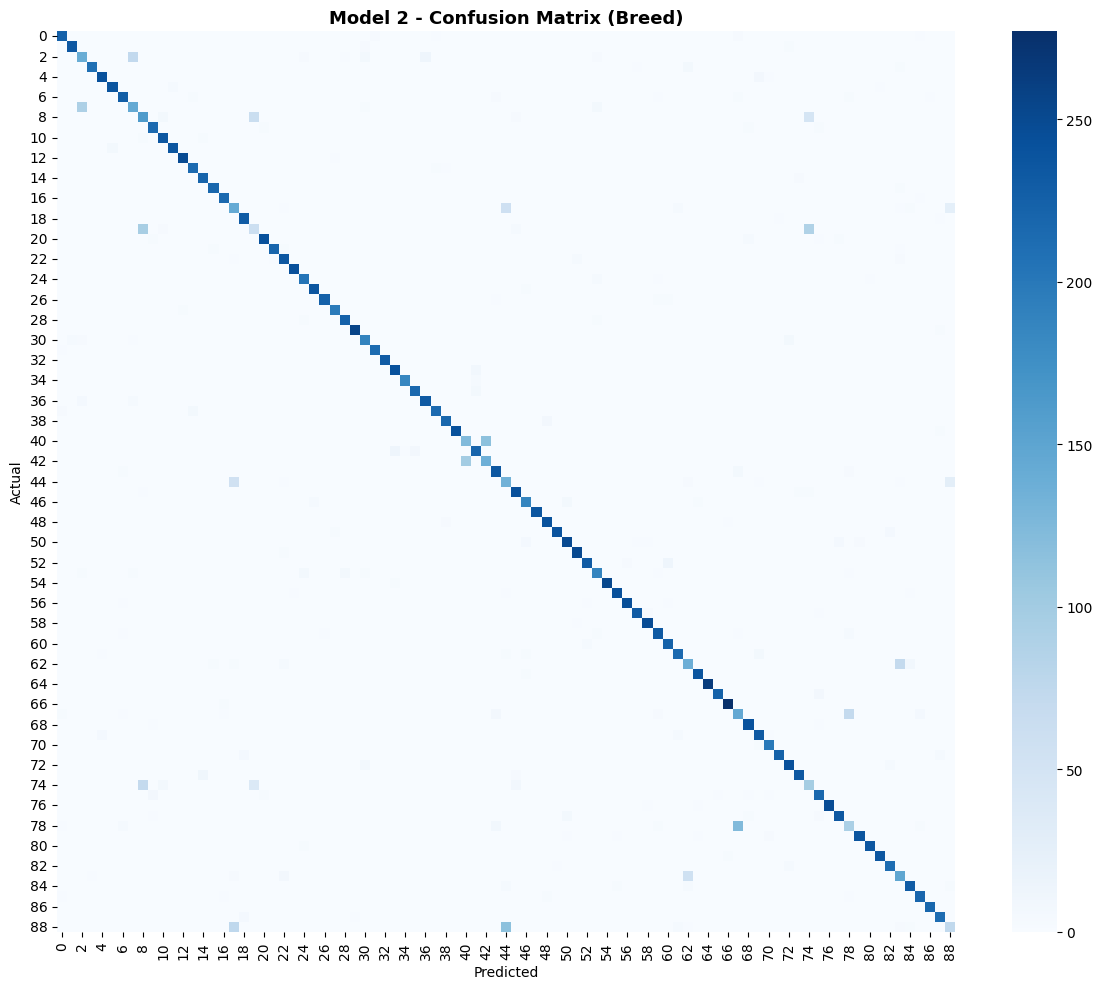

In [116]:
cm_m2 = confusion_matrix(y_test_m2, y_pred_m2)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_m2, cmap='Blues', cbar=True)
plt.title("Model 2 - Confusion Matrix (Breed)", fontsize=13, fontweight='bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

---
## 12. Evaluation Summary

Accuracy alone doesn't tell the whole story, especially for Model 2 with 100 classes — precision, recall, and F1-score (weighted average, to account for any class imbalance) are compared side by side for both models.

In [117]:
from sklearn.metrics import precision_recall_fscore_support

def evaluate_model(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted'
    )
    return {
        'Model': model_name,
        'Accuracy': round(acc, 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1-score': round(f1, 4)
    }

results = pd.DataFrame([
    evaluate_model(y_test_m1, y_pred_m1, 'Model 1 - Animal Type'),
    evaluate_model(y_test_m2, y_pred_m2, 'Model 2 - Breed')
])

results

,Model,Accuracy,Precision,Recall,F1-score
0,Model 1 - Animal Type,0.9138,0.9138,0.9138,0.9138
1,Model 2 - Breed,0.8847,0.8838,0.8847,0.8829


---
## 13. Feature Importance

Random Forest's built-in `feature_importances_` shows which inputs drive each model's decisions the most.

### Model 1 — Top features for Animal Type

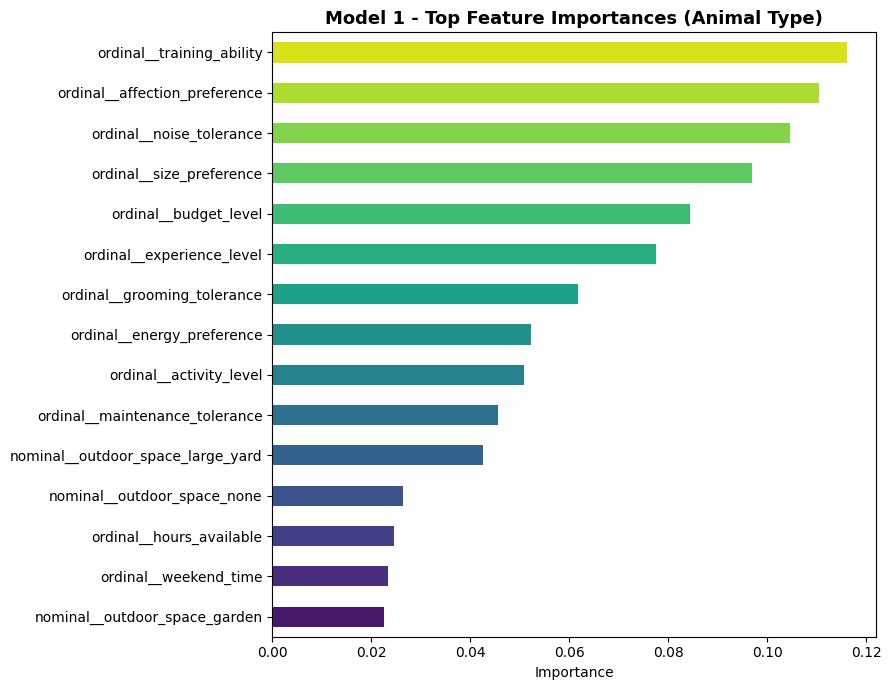

In [118]:
feature_names_m1 = feature_encoder.get_feature_names_out()
importance_m1 = pd.Series(
    model1.feature_importances_, index=feature_names_m1
).sort_values(ascending=False)

top_n = 15
plt.figure(figsize=(9, 7))
importance_m1.head(top_n).sort_values().plot(
    kind='barh', color=sns.color_palette('viridis', top_n)
)
plt.title("Model 1 - Top Feature Importances (Animal Type)", fontsize=13, fontweight='bold')
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### Model 2 — Top features for Breed

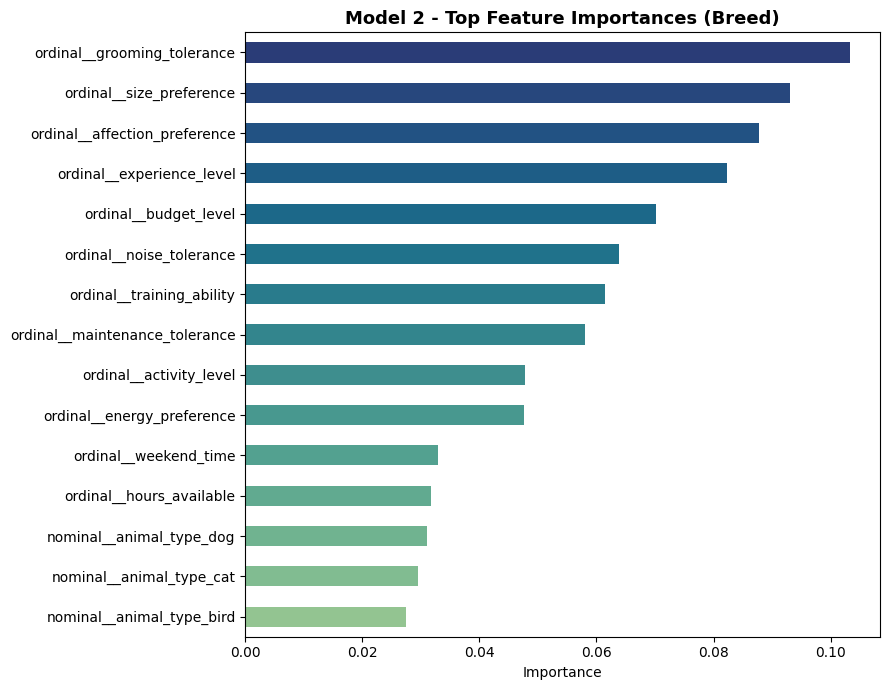

In [119]:
feature_names_m2 = feature_encoder_model2.get_feature_names_out()
importance_m2 = pd.Series(
    model2.feature_importances_, index=feature_names_m2
).sort_values(ascending=False)

plt.figure(figsize=(9, 7))
importance_m2.head(top_n).sort_values().plot(
    kind='barh', color=sns.color_palette('crest', top_n)
)
plt.title("Model 2 - Top Feature Importances (Breed)", fontsize=13, fontweight='bold')
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### 13.3 Hyperparameter Tuning to Reduce Overfitting

Both baseline Random Forests (sections 10.1 and 11.3) show a train/test accuracy gap — a normal side effect of how Random Forests fit training data, but still worth tightening. Baseline train/test accuracy is recomputed at the top of the next cell for reference, then a `GridSearchCV` is run over the settings that most directly control how much a tree can memorize its training data: `n_estimators`, `max_depth`, `min_samples_leaf`, `min_samples_split`, and `max_features`. The grid is deliberately wide — more values per parameter, plus `n_estimators` added to the search — so more configurations are compared before a final one is picked. `class_weight='balanced'` is also included to account for any class imbalance across breeds.

For Model 2, the best-scoring combination from the grid is used directly. For Model 1, picking purely by CV accuracy tends to select the least-regularized option (it still overfits slightly but scores marginally higher), so instead the combination with the smallest train/test gap is chosen among those within 1% accuracy of the best possible score — an explicit trade-off between generalization and raw accuracy.

**Note:** a wider grid means more model fits, so this cell will take noticeably longer to run than a minimal sweep.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# ── Baseline train/test accuracy (for comparison below) ─────────────────────
train_acc_m1 = accuracy_score(y_train_m1, model1.predict(X_train_m1))
test_acc_m1  = accuracy_score(y_test_m1, y_pred_m1)

train_acc_m2 = accuracy_score(y_train_m2, model2.predict(X_train_m2))
test_acc_m2  = accuracy_score(y_test_m2, y_pred_m2)

# ==========================================================
# Model 2 — Breed
# ==========================================================
param_dist_m2 = {
    "n_estimators":      randint(100, 300),
    "max_depth":         [8, 10, 12, 15, 18, 20, 25, 30, None],
    "min_samples_leaf":  randint(1, 8),
    "min_samples_split": randint(2, 20),
    "max_features":      ["sqrt", "log2"],
}

random_m2 = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42, n_jobs=-1, class_weight="balanced"
    ),
    param_distributions=param_dist_m2,
    n_iter=40,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42,
)
random_m2.fit(X_train_m2, y_train_m2)
final_model2 = random_m2.best_estimator_

param_dist_m1 = {
    "n_estimators":      randint(100, 300),
    "max_depth":         [6, 8, 10, 12, 15, 18, 20, 25],
    "min_samples_leaf":  randint(2, 20),
    "min_samples_split": randint(2, 40),
    "max_features":      ["sqrt", "log2"],
}

random_m1 = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42, n_jobs=-1, class_weight="balanced"
    ),
    param_distributions=param_dist_m1,
    n_iter=40,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42,
    return_train_score=True,
)
random_m1.fit(X_train_m1, y_train_m1)

results_m1 = pd.DataFrame(random_m1.cv_results_)
results_m1["cv_gap"] = results_m1["mean_train_score"] - results_m1["mean_test_score"]

GAP_THRESHOLD = 0.02  # anything below this is a "healthy" gap for this model
candidates_m1 = results_m1[results_m1["cv_gap"] < GAP_THRESHOLD]

if candidates_m1.empty:
    candidates_m1 = results_m1.nsmallest(5, "cv_gap")

chosen_row_m1     = candidates_m1.sort_values("mean_test_score", ascending=False).iloc[0]
chosen_params_m1  = chosen_row_m1["params"]

print("Top candidates considered for Model 1 (gap < {:.2f}):".format(GAP_THRESHOLD))
print(candidates_m1[["params", "mean_test_score", "cv_gap"]]
      .sort_values("mean_test_score", ascending=False)
      .head(5)
      .to_string(index=False))
print()

final_model1 = RandomForestClassifier(
    **chosen_params_m1, random_state=42,
    n_jobs=-1, class_weight="balanced"
)
final_model1.fit(X_train_m1, y_train_m1)

# ==========================================================
# Compare tuned models against the baselines from 10.1 / 11.3
# ==========================================================
train_acc_m1_tuned = accuracy_score(y_train_m1, final_model1.predict(X_train_m1))
test_acc_m1_tuned  = accuracy_score(y_test_m1,  final_model1.predict(X_test_m1))

train_acc_m2_tuned = accuracy_score(y_train_m2, final_model2.predict(X_train_m2))
test_acc_m2_tuned  = accuracy_score(y_test_m2,  final_model2.predict(X_test_m2))

print("Model 1 (animal_type)")
print(f"  Best params : {chosen_params_m1}")
print(f"  Baseline    : train {train_acc_m1:.4f}  test {test_acc_m1:.4f}  gap {train_acc_m1 - test_acc_m1:.4f}")
print(f"  Tuned       : train {train_acc_m1_tuned:.4f}  test {test_acc_m1_tuned:.4f}  gap {train_acc_m1_tuned - test_acc_m1_tuned:.4f}")
print()
print("Model 2 (breed)")
print(f"  Best params : {random_m2.best_params_}")
print(f"  Baseline    : train {train_acc_m2:.4f}  test {test_acc_m2:.4f}  gap {train_acc_m2 - test_acc_m2:.4f}")
print(f"  Tuned       : train {train_acc_m2_tuned:.4f}  test {test_acc_m2_tuned:.4f}  gap {train_acc_m2_tuned - test_acc_m2_tuned:.4f}")

Top candidates considered for Model 1 (gap < 0.02):
                                                                                                        params  mean_test_score   cv_gap
{'max_depth': 18, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 13, 'n_estimators': 157}         0.912523 0.012752
 {'max_depth': 25, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}         0.911669 0.009428
 {'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 104}         0.911529 0.009270
{'max_depth': 18, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 25, 'n_estimators': 257}         0.910171 0.008807
{'max_depth': 18, 'max_features': 'sqrt', 'min_samples_leaf': 8, 'min_samples_split': 16, 'n_estimators': 270}         0.907772 0.005396

Model 1 (animal_type)
  Best params : {'max_depth': 18, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 1

---
## 14. Final Pipeline

This section brings everything together:

1. **Save** the two best models and all encoders with `joblib`.
2. **Implement** `recommend_pet(user_answers)` — the single public entry-point.
3. **Evaluate** the end-to-end pipeline on the held-out test set.

### 14.1 Inference Architecture

```
User Answers  (dict)
     │
     ▼
Preprocessing  (feature_encoder  ──►  X_m1_encoded)
     │
     ▼
Model 1        (final_model1)     ──►  predicted_animal_type
     │
     ▼
Append animal_type  (feature_encoder_model2  ──►  X_m2_encoded)
     │
     ▼
Model 2        (final_model2)     ──►  breed probabilities (predict_proba)
     │
     ▼
Sort & decode  ──►  Top-3 breeds + confidence scores
     │
     ▼
Return recommendation dict
```


### 14.2 Save Models and Encoders

In [121]:
import joblib
joblib.dump(final_model1,           'model1_animal_type.pkl',compress=COMPRESS)
joblib.dump(final_model2,           'model2_breed.pkl',compress=COMPRESS)
joblib.dump(feature_encoder,        'feature_encoder.pkl',compress=COMPRESS)        
joblib.dump(feature_encoder_model2, 'feature_encoder_model2.pkl',compress=COMPRESS)
joblib.dump(animal_encoder,         'animal_label_encoder.pkl',compress=COMPRESS)
joblib.dump(breed_encoder,          'breed_label_encoder.pkl',compress=COMPRESS)

['breed_label_encoder.pkl']

---
## 15. Top-3 Accuracy, Recommendation & End-to-End Evaluation

Three interconnected sections:
- **15.1** Top-3 Accuracy — A more accurate metric than Top-1 for the recommendation system
- **15.2** `recommend_pet()` — The complete function ready for production
- **15.3** End-to-End Evaluation — A complete pipeline evaluation on the Test Set

### 15.1 Top-3 Accuracy

Instead of "Is the first strain correct?" we ask "Is the correct strain among the top 3 recommendations?" — which is the most appropriate measure for a recommendation system.

In [122]:
proba_test = final_model2.predict_proba(X_test_m2)

top3_idx = np.argsort(proba_test, axis=1)[:, -3:]

top1_correct = np.array([y_test_m2[i] == top3_idx[i, -1]   for i in range(len(y_test_m2))])
top3_correct = np.array([y_test_m2[i] in top3_idx[i]        for i in range(len(y_test_m2))])

top1_acc = top1_correct.mean()
top3_acc = top3_correct.mean()

print(f"Top-1 Accuracy : {top1_acc:.4f}  ({top1_acc*100:.1f}%)")
print(f"Top-3 Accuracy : {top3_acc:.4f}  ({top3_acc*100:.1f}%)")
print(f"Gain            : +{(top3_acc - top1_acc)*100:.1f}")


Top-1 Accuracy : 0.8864  (88.6%)
Top-3 Accuracy : 0.9858  (98.6%)
Gain            : +9.9


### 15.2 `recommend_pet()`

It takes the user's answers as a dict and returns the type + top 3 strains with confidence percentage.

In [123]:
import joblib

FEATURE_COLS = [
    'housing_type', 'outdoor_space', 'family_type',
    'hours_available', 'weekend_time', 'experience_level',
    'training_ability', 'activity_level', 'noise_tolerance',
    'budget_level', 'maintenance_tolerance', 'size_preference',
    'grooming_tolerance', 'energy_preference', 'affection_preference'
]

def recommend_pet(user_answers: dict, top_n: int = 3) -> dict:

    df = pd.DataFrame([user_answers])[FEATURE_COLS]

    # Model 1 — نوع الحيوان
    X1           = feature_encoder.transform(df)
    animal_enc   = final_model1.predict(X1)[0]
    animal_type  = animal_encoder.inverse_transform([animal_enc])[0]

    # Model 2 — السلالة
    df2              = df.copy()
    df2['animal_type'] = animal_type
    X2               = feature_encoder_model2.transform(df2)
    proba            = final_model2.predict_proba(X2)[0]

    top_idx = np.argsort(proba)[-top_n:][::-1]
    breeds  = [
        {"breed": breed_encoder.classes_[i], "confidence": round(float(proba[i]), 3)}
        for i in top_idx
    ]
    return {"animal_type": animal_type, "breeds": breeds}


sample = {
    'housing_type': 'house', 'outdoor_space': 'large', 'family_type': 'family_with_children',
    'hours_available': 'high', 'weekend_time': 'high', 'experience_level': 'intermediate',
    'training_ability': 'high', 'activity_level': 'high', 'noise_tolerance': 'medium',
    'budget_level': 'medium', 'maintenance_tolerance': 'medium', 'size_preference': 'large',
    'grooming_tolerance': 'medium', 'energy_preference': 'high', 'affection_preference': 'balanced'
}

result = recommend_pet(sample)
print(f"Recommended type: {result['animal_type']}")
print("Top 3 Breeds:")
for b in result['breeds']:
    bar = '█' * int(b['confidence'] * 20)
    print(f"  {b['breed']:<25} {b['confidence']:.1%}  {bar}")


Recommended type: dog
Top 3 Breeds:
  German Shorthaired Pointer 62.9%  ████████████
  Labrador Retriever        17.1%  ███
  Border Collie             9.3%  █


### 15.3 End-to-End Pipeline Evaluation

A complete pipeline evaluation on the entire Test Set — simulates exactly what will happen in production.

In [124]:
test_animal_enc_e2e    = final_model1.predict(X_test_m1)
test_animal_labels_e2e = animal_encoder.inverse_transform(test_animal_enc_e2e)
m1_acc = (test_animal_enc_e2e == y_test_m1).mean()

X_e2e_test              = X_raw_test.copy()
X_e2e_test['animal_type'] = test_animal_labels_e2e
X_e2e_encoded           = feature_encoder_model2.transform(X_e2e_test)

proba_e2e = final_model2.predict_proba(X_e2e_encoded)
top3_e2e  = np.argsort(proba_e2e, axis=1)[:, -3:]

top1_e2e = (np.argmax(proba_e2e, axis=1) == y_test_m2).mean()
top3_e2e_acc = np.array([y_test_m2[i] in top3_e2e[i] for i in range(len(y_test_m2))]).mean()

# ─── ملخص النتائج ──────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'المقياس': [
        'Model 1 — Animal Type Accuracy',
        'Model 2 — Top-1 Breed Accuracy (isolated)',
        'Model 2 — Top-3 Breed Accuracy (isolated)',
        'E2E    — Top-1 Breed Accuracy',
        'E2E    — Top-3 Breed Accuracy',
    ],
    'القيمة': [
        f"{m1_acc:.4f}",
        f"{top1_acc:.4f}",
        f"{top3_acc:.4f}",
        f"{top1_e2e:.4f}",
        f"{top3_e2e_acc:.4f}",
    ]
})
print(summary.to_string(index=False))
print()

# ─── فارق الـ E2E مقارنة بـ Isolated ──────────────────────────────────────
delta1 = top1_e2e - top1_acc
delta3 = top3_e2e_acc - top3_acc
print(f"أثر خطأ Model 1 على Top-1 : {delta1:+.4f}  ({delta1*100:+.2f}%)")
print(f"أثر خطأ Model 1 على Top-3 : {delta3:+.4f}  ({delta3*100:+.2f}%)")
print()


                                  المقياس القيمة
           Model 1 — Animal Type Accuracy 0.9076
Model 2 — Top-1 Breed Accuracy (isolated) 0.8864
Model 2 — Top-3 Breed Accuracy (isolated) 0.9858
            E2E    — Top-1 Breed Accuracy 0.8865
            E2E    — Top-3 Breed Accuracy 0.9860

أثر خطأ Model 1 على Top-1 : +0.0000  (+0.00%)
أثر خطأ Model 1 على Top-3 : +0.0002  (+0.02%)

